In [1]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [3]:
train_df.head()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


In [4]:
train_df.shape

(18000, 17)

In [5]:
train_df.columns

Index(['id', 'date', 'region', 'channel', 'product_category',
       'customer_segment', 'ad_spend', 'price', 'discount_rate',
       'market_reach', 'impressions', 'click_through_rate',
       'competition_index', 'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue'],
      dtype='object')

In [6]:
train_df.dtypes

id                           int64
date                        object
region                      object
channel                     object
product_category            object
customer_segment            object
ad_spend                   float64
price                      float64
discount_rate              float64
market_reach               float64
impressions                  int64
click_through_rate         float64
competition_index          float64
seasonality_index          float64
campaign_duration_days     float64
customer_lifetime_value    float64
sales_revenue              float64
dtype: object

In [7]:
train_df.isnull().sum()

id                            0
date                          0
region                        0
channel                       0
product_category              0
customer_segment              0
ad_spend                    658
price                         0
discount_rate               755
market_reach                686
impressions                   0
click_through_rate          713
competition_index           707
seasonality_index             0
campaign_duration_days     1513
customer_lifetime_value     743
sales_revenue                 0
dtype: int64

In [8]:
#Function to convert K/M values to numbers

def convert_spend(x):
    if isinstance(x,str):
        x= x.replace(",", "").strip()

        if "K" in x:
            return float(x.replace("K",""))*1000
        elif "M" in x:
            return float(x.replace("M", ""))*1000000
        else:
            return float()
    return x


In [9]:
#Apply conversion to ad_spend column

train_df["ad_spend"] = train_df["ad_spend"].apply(convert_spend)
test_df["ad_spend"] = test_df["ad_spend"].apply(convert_spend)

In [10]:
train_df.isnull().sum()

id                            0
date                          0
region                        0
channel                       0
product_category              0
customer_segment              0
ad_spend                    658
price                         0
discount_rate               755
market_reach                686
impressions                   0
click_through_rate          713
competition_index           707
seasonality_index             0
campaign_duration_days     1513
customer_lifetime_value     743
sales_revenue                 0
dtype: int64

In [11]:
#fill numeric missing values

num_cols = train_df.select_dtypes(include=np.number).columns

train_df[num_cols] = train_df[num_cols].fillna(train_df[num_cols].median())

In [12]:
#fill categorical missing values

cat_cols = train_df.select_dtypes(include = "object").columns

train_df[cat_cols] = train_df[cat_cols].fillna("Unknown")

In [13]:
train_df.isnull().sum()

id                         0
date                       0
region                     0
channel                    0
product_category           0
customer_segment           0
ad_spend                   0
price                      0
discount_rate              0
market_reach               0
impressions                0
click_through_rate         0
competition_index          0
seasonality_index          0
campaign_duration_days     0
customer_lifetime_value    0
sales_revenue              0
dtype: int64

In [14]:
#region vs customer_segment

region_segment = train_df.groupby(["region","customer_segment"]).size().reset_index(name="count")
print(region_segment)

     region customer_segment  count
0   Central           Budget     18
1   Central          Premium     62
2   Central         Standard     29
3      East           Budget     30
4      East          Premium    239
5      East         Standard    105
6     NORTH           Budget      7
7     NORTH          Premium    172
8     NORTH         Standard     30
9     Norht           Budget      7
10    Norht          Premium    207
11    Norht         Standard     34
12     Nort           Budget     10
13     Nort          Premium    163
14     Nort         Standard     27
15    North           Budget    692
16    North          Premium  13167
17    North         Standard   2446
18    South           Budget      7
19    South          Premium     22
20    South         Standard      8
21     West           Budget      2
22     West          Premium     52
23     West         Standard     23
24    north           Budget     12
25    north          Premium    204
26    north         Standard

In [15]:
#region wise channel spend

region_channel = train_df.groupby(["region","channel"]) ["ad_spend"].sum().reset_index()

print(region_channel)

     region       channel     ad_spend
0   Central     Affiliate  2151.379337
1   Central         Email  1783.718019
2   Central    Influencer    56.940000
3   Central        Search  1466.129451
4   Central  Social Media  2321.564578
..      ...           ...          ...
71   north     Influencer   561.600000
72   north         Search  1958.987933
73   north   Social Media  1073.280000
74   north             TV   474.820000
75   north   social Media    15.420000

[76 rows x 3 columns]


In [16]:
#Product category performance

product_sales = train_df.groupby(["product_category"])['ad_spend'].sum().sort_values(ascending=False).round(2)

print(product_sales)

product_category
General       382742.33
Storage       165897.20
Seasonal       83683.93
Stationery     61818.29
Kitchen        42870.13
Lighting       35111.44
Name: ad_spend, dtype: float64


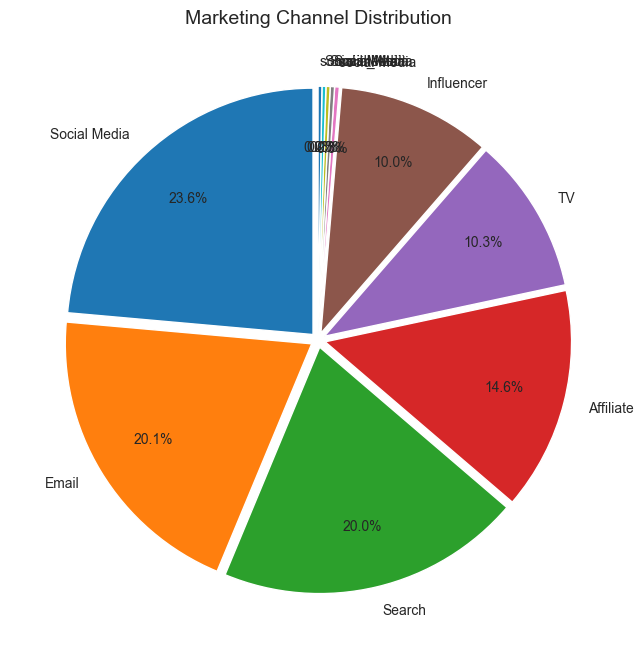

In [17]:
#Pie chart for marketing channel 

channel_count = train_df["channel"].value_counts()
sns.set_style("whitegrid") 
plt.figure(figsize=(8,8))

plt.pie(channel_count , 
        labels=channel_count.index,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.75,
        explode=[0.03]*len(channel_count)
        )
plt.title("Marketing Channel Distribution", fontsize = 14)
plt.show()

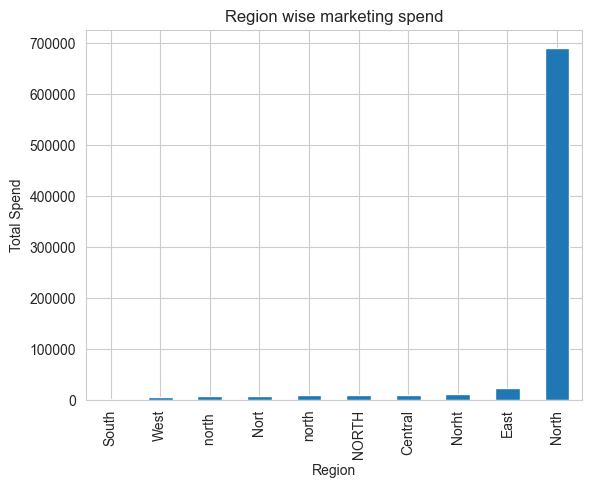

In [18]:
#Region wise marketing spend

region_spend = train_df.groupby("region")["ad_spend"].sum().sort_values()

region_spend.plot(kind ="bar")

plt.title("Region wise marketing spend")
plt.xlabel("Region")
plt.ylabel("Total Spend")

plt.show()

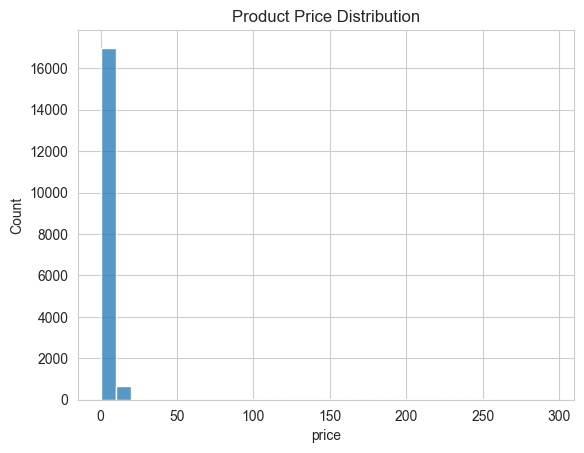

In [19]:
#price distribution
sns.histplot(train_df["price"], bins=30)
plt.title("Product Price Distribution")

plt.show()

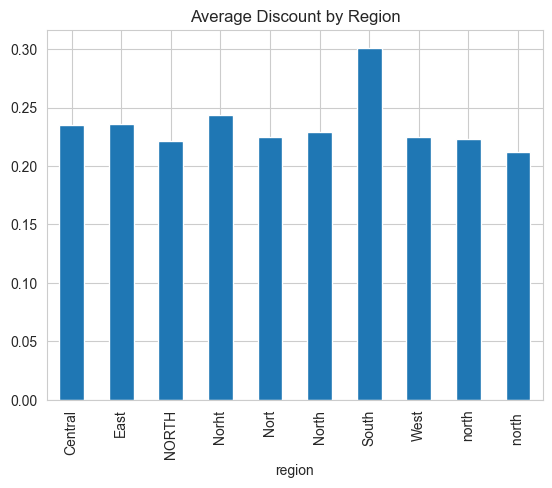

In [20]:
#Region wise discount rate
discount_region = train_df.groupby("region")["discount_rate"].mean()

discount_region.plot(kind = "bar")

plt.title("Average Discount by Region")
plt.show()

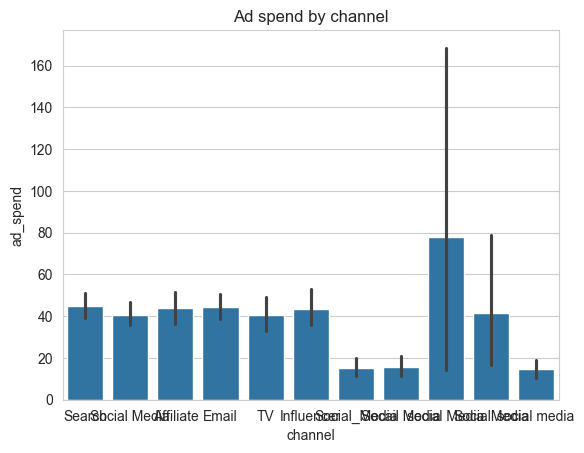

In [21]:
#Channel Performance

sns.barplot(
    x="channel",
    y="ad_spend",
    data=train_df
)
plt.title("Ad spend by channel")
plt.show()

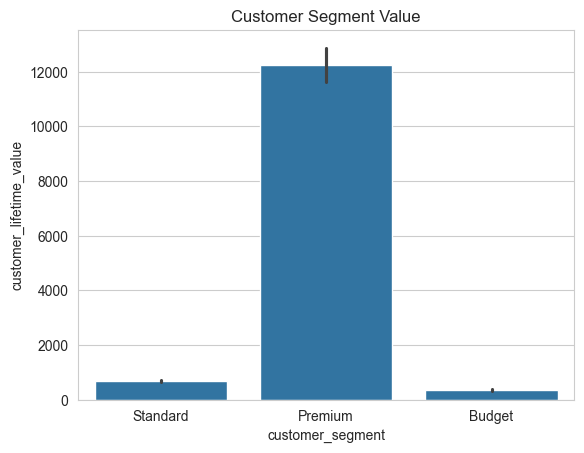

In [22]:
#customer lifetime value by segment
sns.barplot(
    x="customer_segment",
    y="customer_lifetime_value",
    data=train_df
)

plt.title("Customer Segment Value")
plt.show()

In [29]:
#Top revenue product 

top_product = train_df.groupby("product_category")["sales_revenue"].sum().sort_values(ascending = False)

top_product.head(10)


product_category
General       1.166083e+06
Storage       5.504540e+05
Seasonal      2.687556e+05
Stationery    2.396103e+05
Kitchen       1.370191e+05
Lighting      1.077671e+05
Name: sales_revenue, dtype: float64

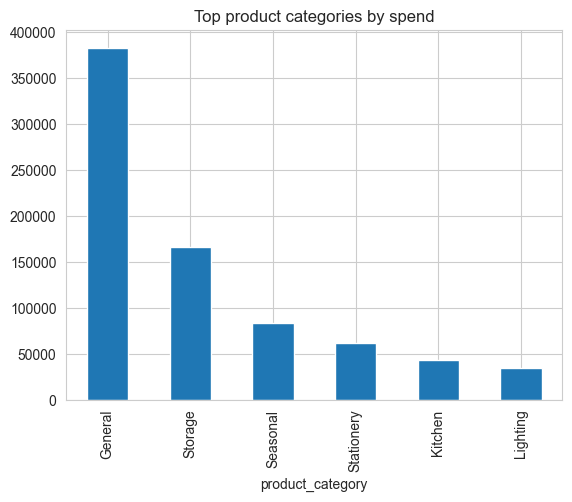

In [23]:
#Top selling product categories

top_products = train_df.groupby("product_category")["ad_spend"].sum().sort_values(ascending = False)

top_products.plot(kind = "bar")
plt.title("Top product categories by spend")
plt.show()

In [24]:
train_df.columns
train_df.head()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924
